In [53]:
#NAMA : Muhammad Khairul Bin Nasir
#NIM : 231061005
#PRODI : Sains Data 23


In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
data = pd.read_csv("/content/hotel_guests_dataset (1).csv")

In [56]:
data.head()

,Unnamed: 0,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,0,dsullivan@example.net,False,BASIC,8.324971,04 Apr 2020,23 Apr 2020,146.834507,"90469 Karla Knolls Apt. 781\nSusanberg, NC 28401",5161033759518983
1,1,steven59@example.org,False,BASIC,NaN,27 Jun 2020,16 Aug 2020,185.497813,"1080 Ashley Creek Apt. 622\nWest Amy, NM 25058",4133047413145475690
2,2,brandon15@example.net,False,BASIC,22.269158,13 Apr 2020,07 Apr 2020,151.115528,"99923 Anderson Trace Suite 861\nNorth Haley, T...",4977328103788
3,3,humphreyjennifer@example.net,False,BASIC,25.468647,22 May 2020,08 Jun 2020,182.468031,"9301 John Parkways\nThomasland, OH 61350",3524946844839485
4,4,joshuabrown@example.net,False,BASIC,19.778311,14 Nov 2019,27 Oct 2019,195.497743,"126 George Tunnel\nDuranstad, MS 95176",4446905799576890978


In [57]:
data.drop(['Unnamed: 0','guest_email','checkin_date','checkout_date','billing_address','credit_card_number'], inplace=True, axis=1)

In [58]:
data.isna().sum()

,0
has_rewards,0
room_type,0
amenities_fee,184
room_rate,0


In [76]:
data.dropna(inplace=True)

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1816 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   has_rewards    1816 non-null   int64  
 1   room_type      1816 non-null   int64  
 2   amenities_fee  1816 non-null   float64
 3   room_rate      1816 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 70.9 KB


In [78]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
data['room_type']= label_encoder.fit_transform(data['room_type'])

data["has_rewards"] = data.has_rewards.astype(int)

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1816 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   has_rewards    1816 non-null   int64  
 1   room_type      1816 non-null   int64  
 2   amenities_fee  1816 non-null   float64
 3   room_rate      1816 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 70.9 KB


<ipython-input-80-aca7513fc2bb>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data['room_type'], y=data['room_rate'], palette='inferno');


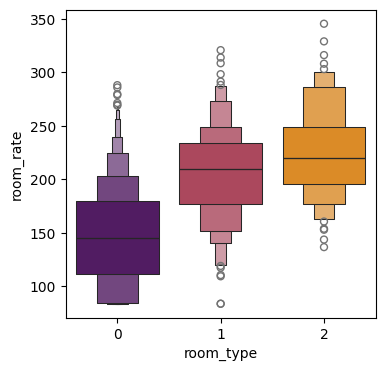

In [80]:
plt.figure(figsize=(4,4))
sns.boxenplot(x=data['room_type'], y=data['room_rate'], palette='inferno');

distribusi ungu jumlah tindakan yang diambil sel cenderung rendah, dengan median dan nilai tengahnya berada di sekitar 175.
manakala distribusi merah muda jumlah tindakkan yang diambil bervariasi dengan median dan nilai tengahnya 275 dan distribusi oren mengambil tindakan

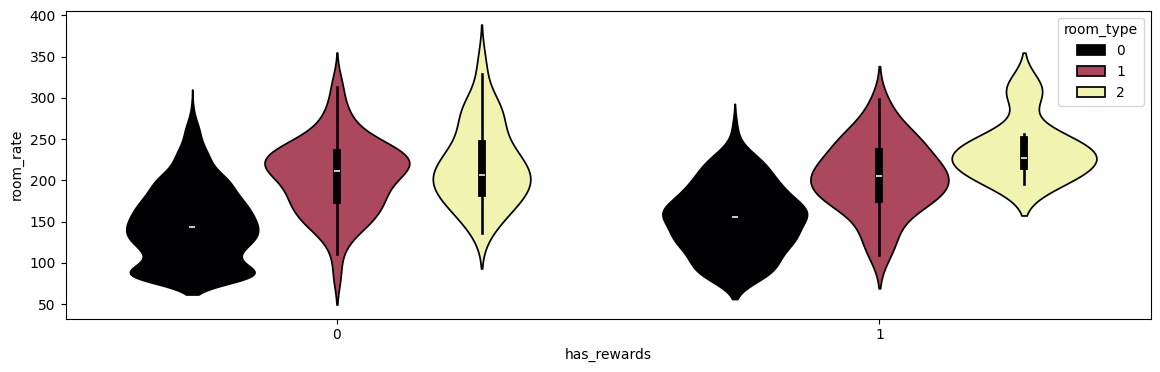

In [81]:
plt.figure(figsize=(14,4))
sns.violinplot(data=data,y="room_rate", x="has_rewards", palette='inferno',hue="room_type");

#Sumbu X : has_rewards
Menunjukkan apakah pelanggan memiliki program hadiah (rewards) atau tidak.

0: Tidak memiliki rewards
1: Memiliki rewards

Menampilkan harga kamar (room rate). Ini adalah variabel numerik yang mengindikasikan berapa biaya kamar dalam suatu rentang tertentu.

Warna Violin Plot: room_type
Menunjukkan tipe kamar. Ada tiga kategori:

Hitam (0)
Merah (1)
Kuning (2)

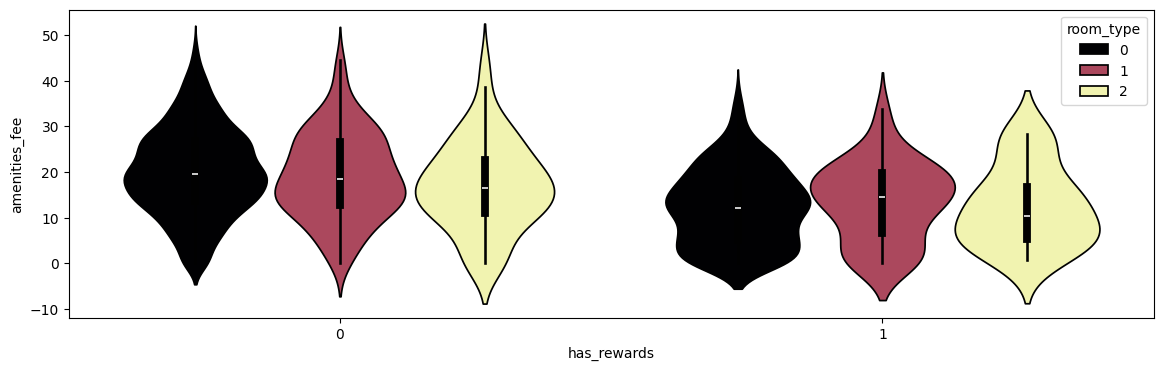

In [82]:
plt.figure(figsize=(14,4))
sns.violinplot(data=data,y="amenities_fee", x="has_rewards", palette='inferno',hue="room_type");

Sumbu y menunjukkan variabel "amenities_fee" yang merepresentasikan semacam biaya atau metrik yang terkait dengan kamar-kamar.

Titik-titik data dalam plot ditampilkan sebagai simbol berbentuk berlian, dengan warna dan bentuk simbol-simbol tersebut mengindikasikan nilai dari variabel "room_type". Terdapat tiga tipe kamar yang berbeda (0, 1, dan 2).

In [83]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [88]:
target_col='room_type'
features = [i for i in data.columns]
features.remove('room_type')
X=data[features]
y=data[target_col]

In [90]:
X_train,X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.3, random_state=100)

In [91]:
rfmodel=RandomForestClassifier()
rfmodel.fit(X_train, Y_train)
rfpred = rfmodel.predict(X_test)

In [92]:
xgmodel=XGBClassifier()
xgmodel.fit(X_train, Y_train)
xgpred = xgmodel.predict(X_test)

In [93]:
gbmodel=GradientBoostingClassifier()
gbmodel.fit(X_train, Y_train)
gbpred = gbmodel.predict(X_test)


In [94]:
print("Accuracy of RandomForestClassifier : ",accuracy_score(Y_test, rfpred))
print("Accuracy of XGBClassifier : ",accuracy_score(Y_test, xgpred))
print("Accuracy of GradientBoostingClassifier : ",accuracy_score(Y_test, gbpred))

Accuracy of RandomForestClassifier :  0.8623853211009175
Accuracy of XGBClassifier :  0.8623853211009175
Accuracy of GradientBoostingClassifier :  0.8495412844036697
